In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

In [ ]:
from app.db.vector_db import get_qdrant_client
from app.core.config import settings

client = get_qdrant_client()
points = client.retrieve(
    collection_name=settings.QDRANT_COLLECTION_NAME,
    ids=[41025],
    with_payload=True
)

if points:
    print(f"ID: {points[0].id}")
    print(f"Payload: {points[0].payload}")
else:
    print("Point not found")

e:\pythonProject\P-plip-inference\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ID: 41025
Payload: {'no': 97672, 'title': '백년짬뽕 메이챤', 'overview': '백년짬뽕 메이챤은 경기도 안산시 단원구 신길동에 위치한 중식당입니다. 이곳은 짬뽕을 주 메뉴로 맛있는 중식 요리를 제공하는 곳으로 유명합니다. 특히, 얼큰하고 진한 국물의 짬뽕은 많은 손님들에게 사랑받고 있습니다. 백년짬뽕 메이챤은 가족 모임이나 친구들과의 외식, 또는 가벼운 식사나 회식을 위한 좋은 장소입니다. 맛집 탐방을 즐기는 분들이나 중식 요리를 좋아하는 분들이 방문해 보면 좋을 곳입니다.', 'content_type': '음식점', 'addr1': '경기도 안산시 단원구 중앙대로 97', 'addr2': '', 'first_image1': 'http://tong.visitkorea.or.kr/cms/resource/01/2860501_image2_1.JPG', 'first_image2': 'http://tong.visitkorea.or.kr/cms/resource/01/2860501_image3_1.JPG', 'content_id': 2860504, 'homepage': '', 'tag_names': '맛집탐방, 가족외식, 얼큰한, 짬뽕맛집, 푸짐한, 안산시맛집', 'location': {'lat': 37.3312636586, 'lon': 126.7529731494}}


In [ ]:
from typing import TypedDict, Literal
from app.agents.enum import ContentTypes
from langchain_classic.schema import Document   
from typing import List

class AttractionState(TypedDict):
    query: str
    content_type: ContentTypes
    lat: float
    lng: float
    k: int
    m: int
    results: List[Document]

e:\pythonProject\P-plip-inference\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from app.core.llm import mini_llm
from app.schemas.chat_schema import ContentTypeExtract
from langchain_core.output_parsers import JsonOutputParser
from app.agents.prompts.templates import content_type_extract_template

parser = JsonOutputParser(pydantic_object=ContentTypeExtract)

def content_type_extraction(state: AttractionState):
    user_query = state['query']
    prompt = content_type_extract_template
    structured_llm = mini_llm.with_structured_output(ContentTypeExtract)
    chain = prompt | structured_llm

    state['content_type'] = chain.invoke({"query": user_query})
    print("content_type: ", state['content_type'])
    return state

In [ ]:
from app.db.vector_db import get_vector_store
from app.db.filters import build_geo_fileter_with_content_type
def retrieve_attractions(state:AttractionState):

    user_query = state['query']
    lat = state['lat']
    lon = state['lng']
    m = state['m']
    k = state['k']
    content_type = state['content_type'].content_type.value
    print("query:", user_query)    
    search_filter = None

    if lat is not None and lon is not None:
        if content_type is None:
            search_filter = build_geo_fileter(lat, lon, radius_m=m)
        else:
            search_filter = build_geo_fileter_with_content_type(lat, lon, radius_m=m, content_type=content_type)
    
    vector_store = get_vector_store()

    docs = vector_store.similarity_search(
        query=user_query,
        filter=search_filter,
        k=k
    )
    state['results'] = docs
    return state

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def query_rewrite(state: AttractionState):
    """(옵션) 타입을 못 찾았을 때 쿼리를 수정하거나 기본값 설정"""
    original_query = state['query']
    print(f"⚠️ 타입을 명확히 알 수 없어 쿼리를 보정합니다. (입력: {original_query})")
    
    system_prompt = (
        "당신은 관광지 및 맛집 추천 시스템의 입력 보정 도우미입니다. "
        "사용자의 질문에서 의도(카테고리)를 파악하기 어려워 검색에 실패했습니다. "
        "사용자의 원래 의도를 유지하되, 검색 시스템이 잘 이해할 수 있도록 "
        "질문을 **더 명확하고 구체적인 한국어 문장**으로 다시 작성해주세요. "
        "\n\n"
        "[지침]"
        "- '맛집', '관광지', '카페', '산책로' 같은 명확한 키워드를 포함시키려고 노력하세요."
        "- 질문이 너무 모호하다면, 일반적인 '인기 있는 관광지 추천해줘' 형태로 변경하세요."
        "- 오직 **수정된 쿼리 문장 하나만** 출력하세요 (따옴표나 설명 제외)."
    )
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "{query}"),
    ])
    
    chain = prompt | mini_llm | StrOutputParser()
    
    new_query = chain.invoke({"query": original_query})
    
    # 혹시 모를 앞뒤 공백 제거
    new_query = new_query.strip()
    
    print(f"✅ 보정된 쿼리: {new_query}")
    
    return {"query": new_query}

In [ ]:
def content_type_check(state: AttractionState) -> Literal[retrieve_attractions.__name__, content_type_extraction.__name__]:
    
    if state['content_type'].content_type in ContentTypes:
        return retrieve_attractions.__name__
    else:
        return query_rewrite.__name__

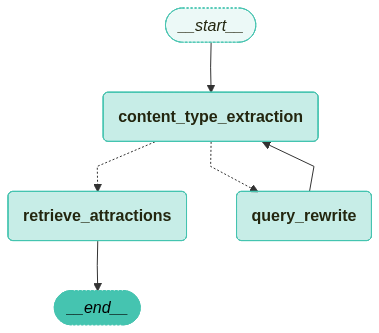

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_teddynote.graphs import visualize_graph
graph = StateGraph(AttractionState)

graph.add_node(content_type_extraction.__name__, content_type_extraction)
graph.add_node(retrieve_attractions.__name__, retrieve_attractions)
graph.add_node(query_rewrite.__name__, query_rewrite)
graph.add_edge(START, content_type_extraction.__name__)
graph.add_conditional_edges(
    content_type_extraction.__name__,
    content_type_check,
    {
        retrieve_attractions.__name__ : retrieve_attractions.__name__,
        query_rewrite.__name__ : query_rewrite.__name__
    }
)
graph.add_edge(query_rewrite.__name__, content_type_extraction.__name__)
graph.add_edge(retrieve_attractions.__name__, END)

suggest_graph = graph.compile()

visualize_graph(suggest_graph)

In [ ]:
result = suggest_graph.invoke({
    "query": "날씨도 쌀쌀한데 주변에 몸 녹일만한 카페 추천해줘",
    "lat": 37.5666,
    "lng": 126.9781,
    "m": 1000,
    "k": 5
})

print(result['results'])